In [1]:
%load_ext autoreload
%autoreload 2

from cfspopcon.jax_compatible.helpers import integrate_profile_over_volume
from popsim.simulators.simple_power_balance.build_default import build_default
from popsim.simulators.simple_power_balance.simple_model import Params, Simulator
from cfspopcon.jax_compatible.helpers import integrate_profile_over_volume
import equinox as eqx
import jax
import jax.numpy as jnp
import pprint
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

def module_to_dict(module):
    return {k: v for k, v in module.__dict__.items() if not k.startswith('_')}

# Build a default simulation
model, state, params = build_default()
derivs, debug = model(state, params, debug_info=True)

In [2]:
"""
Build a second model that uses a naive volume integrator.
"""
plasma_volume = jnp.trapz(model.volume_integrator.dV_drho, x=model.volume_integrator.rho)

model2 = eqx.tree_at(lambda m: m.volume_integrator, model, lambda array: integrate_profile_over_volume(array, model.volume_integrator.rho, plasma_volume))

dervis2, debug2 = model2(state, params, debug_info=True)

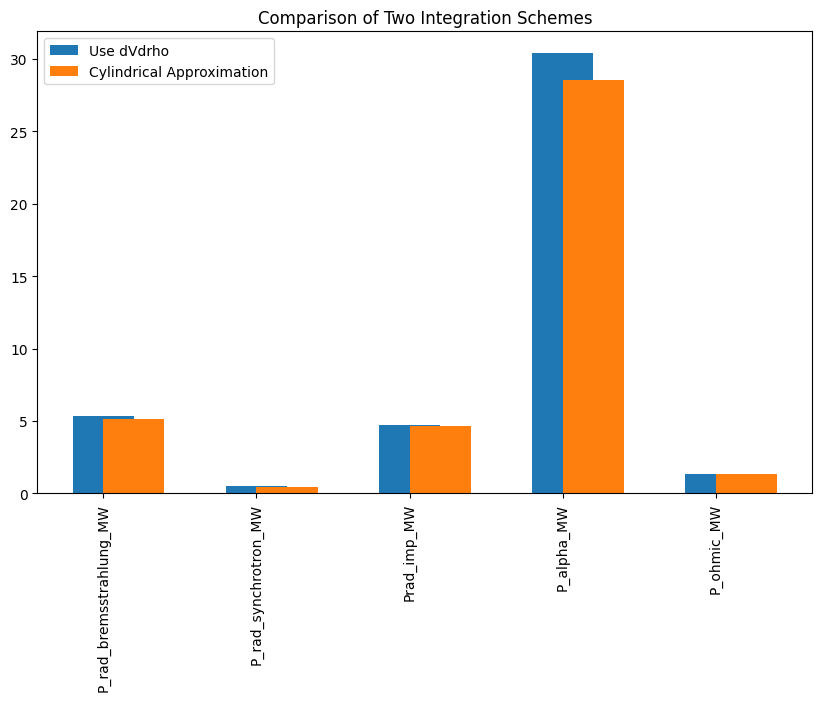

In [3]:
def compare(dict1, dict2):
    # Extract keys and values for plotting
    keys = list(dict1.keys())
    values1 = list(dict1.values())
    values2 = list(dict2.values())

    # Creating a bar plot
    plt.figure(figsize=(10, 6))
    plt.bar([x for x in keys], values1, width=0.4, label='Use dVdrho', align='center')
    plt.bar([x for x in keys], values2, width=0.4, label='Cylindrical Approximation', align='edge')
    plt.xticks(range(len(keys)), keys, rotation='vertical')  # Rotate x-axis labels
    plt.title('Comparison of Two Integration Schemes')
    plt.legend()

    # Show the plot
    plt.show()

debug_vars = [
    "P_rad_bremsstrahlung_MW",
    "P_rad_synchrotron_MW",
    "Prad_imp_MW",
    "P_alpha_MW",
    "P_ohmic_MW",
]

def filter_dic_to_scalars(d):
    return {k: v for k, v in d.items() if k in debug_vars}

compare(filter_dic_to_scalars(debug), filter_dic_to_scalars(debug2))

In [4]:
sim = Simulator(model)
sim2 = Simulator(model2)

ts = jnp.linspace(0.0, 5.0, 50)
sol, derivs, debugs = sim(ts, state, params)
sol2, derivs2, debugs2 = sim2(ts, state, params)

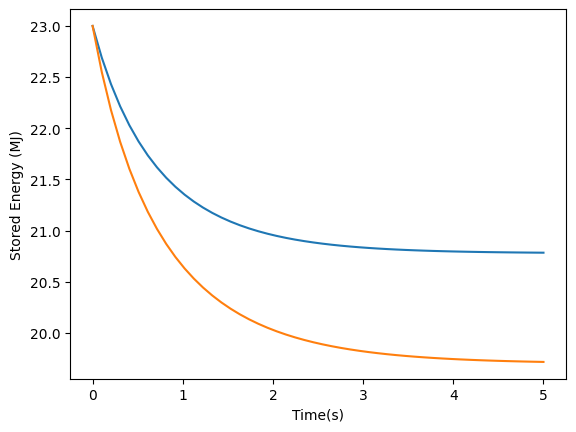

In [5]:
plt.plot(ts, sol.ys.stored_energy, label="Use dVdrho")
plt.plot(ts, sol2.ys.stored_energy, label="Cylindrical Approximation")
plt.xlabel("Time(s)")
plt.ylabel("Stored Energy (MJ)")
plt.show()